In [1]:
import pandas as pd
from PIL import Image
import os
import sys
import json
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import f1_score

In [2]:
%matplotlib inline

In [3]:
# Base Path
base_path = "E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Exercise 8.4: Generating Adversarial Examples

In [5]:
# Dataset Class
class CarlaDataset(Dataset):
    def __init__(self, csv_file, img_dir, label_column, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
# Load Vehicle Model
model_vehicle = models.resnet18(weights=None)

model_vehicle.fc = nn.Linear(
    model_vehicle.fc.in_features,
    1
)

model_vehicle.load_state_dict(
    torch.load(
        "vehicle.pth",
        map_location=device
    )
)

model_vehicle = model_vehicle.to(device)

model_vehicle.eval()

print("Vehicle model loaded")

Vehicle model loaded


In [8]:
# Load Pedestrian Model
model_pedestrian = models.resnet18(weights=None)

model_pedestrian.fc = nn.Linear(
    model_pedestrian.fc.in_features,
    1
)

model_pedestrian.load_state_dict(
    torch.load(
        "pedestrian.pth",
        map_location=device
    )
)

model_pedestrian = model_pedestrian.to(device)

model_pedestrian.eval()

print("Pedestrian model loaded")

Pedestrian model loaded


In [9]:
# Load Traffic Model
model_traffic = models.resnet18(weights=None)

model_traffic.fc = nn.Linear(
    model_traffic.fc.in_features,
    1
)

model_traffic.load_state_dict(
    torch.load(
        "traffic.pth",
        map_location=device
    )
)

model_traffic = model_traffic.to(device)

model_traffic.eval()

print("Traffic-light model loaded")

Traffic-light model loaded


In [10]:
# Create Test Datasets
test_vehicle = CarlaDataset(
    f"{base_path}/test/labels.csv",
    f"{base_path}/test/rgb-front",
    "has_vehicle",
    transform
)

test_pedestrian = CarlaDataset(
    f"{base_path}/test/labels.csv",
    f"{base_path}/test/rgb-front",
    "has_pedestrian",
    transform
)

test_traffic = CarlaDataset(
    f"{base_path}/test/labels.csv",
    f"{base_path}/test/rgb-front",
    "has_traffic_light",
    transform
)

In [11]:
# Create DataLoaders
loader_vehicle = DataLoader(
    test_vehicle,
    batch_size=1,
    shuffle=False
)

loader_pedestrian = DataLoader(
    test_pedestrian,
    batch_size=1,
    shuffle=False
)

loader_traffic = DataLoader(
    test_traffic,
    batch_size=1,
    shuffle=False
)

## Exercise 8.4.1

In [12]:
# FGSM Function
def fgsm_attack(image, epsilon, data_grad):

    sign_data_grad = data_grad.sign()

    perturbed_image = image + epsilon * sign_data_grad

    return perturbed_image

## Exercise 8.4.2

In [13]:
# Generate Adversarial Examples
criterion = nn.BCEWithLogitsLoss()

epsilons = [0.01, 0.05, 0.1]

adv_examples_vehicle = {}

image, label = next(iter(loader_vehicle))

image = image.to(device)
label = label.unsqueeze(1).to(device)

for eps in epsilons:

    img = image.clone().detach()

    img.requires_grad = True

    output = model_vehicle(img)

    loss = criterion(output, label)

    model_vehicle.zero_grad()

    loss.backward()

    data_grad = img.grad.data

    adv_image = fgsm_attack(
        img,
        eps,
        data_grad
    )

    adv_examples_vehicle[eps] = adv_image.detach()

print("Adversarial examples generated")

Adversarial examples generated


In [14]:
# Denormalization Function
mean = torch.tensor(
    [0.485,0.456,0.406]
).view(3,1,1)

std = torch.tensor(
    [0.229,0.224,0.225]
).view(3,1,1)

def denormalize(img):

    img = img.cpu()

    img = img.squeeze(0)

    img = img * std + mean

    img = torch.clamp(img,0,1)

    return img.permute(1,2,0).numpy()

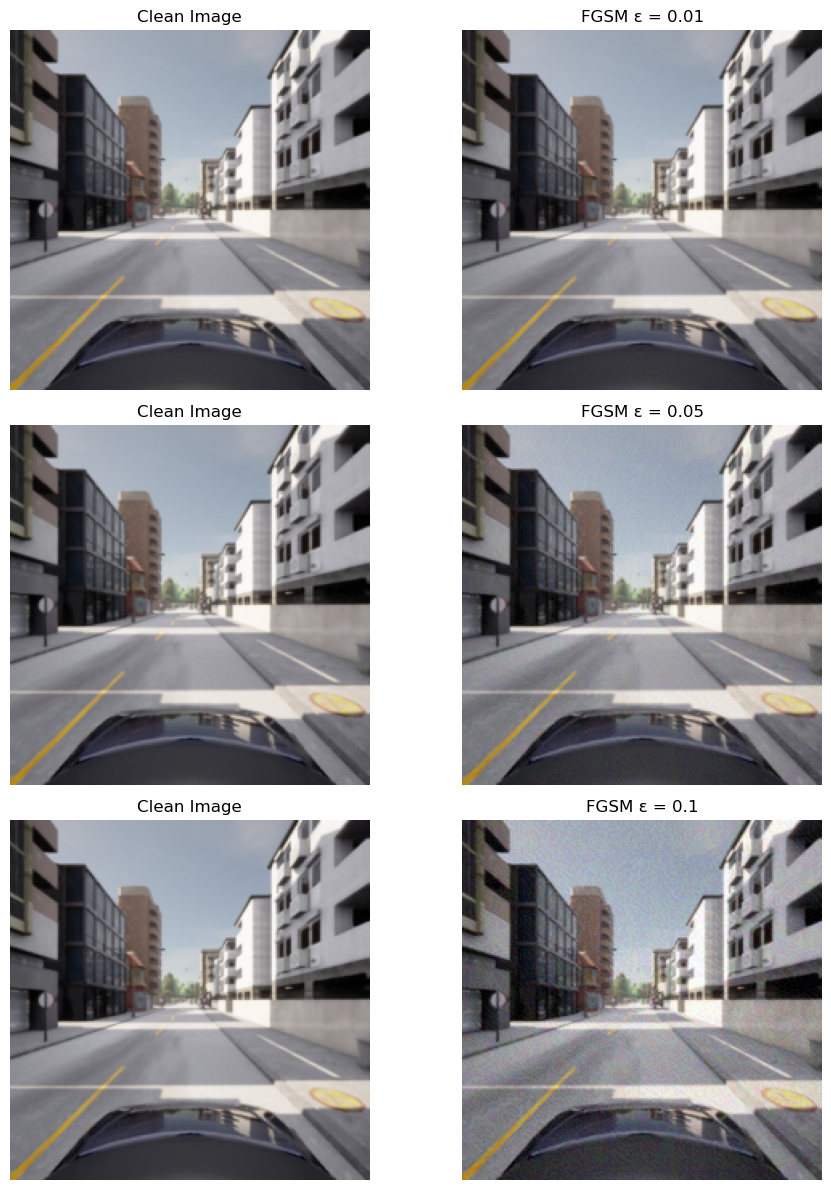

In [15]:
# Exercise 8.4.3
fig, axes = plt.subplots(
    3,
    2,
    figsize=(10,12)
)

for idx, eps in enumerate(epsilons):

    axes[idx,0].imshow(
        denormalize(image)
    )

    axes[idx,0].set_title(
        "Clean Image"
    )

    axes[idx,0].axis("off")

    axes[idx,1].imshow(
        denormalize(
            adv_examples_vehicle[eps]
        )
    )

    axes[idx,1].set_title(
        f"FGSM ε = {eps}"
    )

    axes[idx,1].axis("off")

plt.tight_layout()

plt.show()

## Evalusation 

In [16]:
def evaluate_fgsm_recall(
        model,
        dataset,
        epsilon,
        device,
        sample_size=100):

    criterion = nn.BCEWithLogitsLoss()

    indices = random.sample(
        range(len(dataset)),
        min(sample_size, len(dataset))
    )

    clean_true = []
    clean_pred = []

    adv_true = []
    adv_pred = []

    model.eval()

    for idx in indices:

        image, label = dataset[idx]

        image = image.unsqueeze(0).to(device)

        label_tensor = torch.tensor(
            [[label]],
            dtype=torch.float32
        ).to(device)

        image.requires_grad = True

        # ------------------
        # CLEAN PREDICTION
        # ------------------

        output = model(image)

        prediction = (
            torch.sigmoid(output) > 0.5
        ).float()

        clean_true.append(
            int(label)
        )

        clean_pred.append(
            int(prediction.item())
        )

        # ------------------
        # FGSM
        # ------------------

        loss = criterion(
            output,
            label_tensor
        )

        model.zero_grad()

        loss.backward()

        data_grad = image.grad.data

        adv_image = fgsm_attack(
            image,
            epsilon,
            data_grad
        )

        # ------------------
        # ADVERSARIAL PREDICTION
        # ------------------

        adv_output = model(
            adv_image
        )

        adv_prediction = (
            torch.sigmoid(
                adv_output
            ) > 0.5
        ).float()

        adv_true.append(
            int(label)
        )

        adv_pred.append(
            int(
                adv_prediction.item()
            )
        )

    clean_recall = recall_score(
        clean_true,
        clean_pred,
        zero_division=0
    )

    adv_recall = recall_score(
        adv_true,
        adv_pred,
        zero_division=0
    )

    recall_drop = (
        clean_recall
        -
        adv_recall
    )

    return (
        clean_recall,
        adv_recall,
        recall_drop
    )

In [17]:
# Evaluate vehicle
epsilons = [0.01, 0.05, 0.1]

vehicle_results = []

for eps in epsilons:

    clean_recall, adv_recall, drop = \
        evaluate_fgsm_recall(
            model_vehicle,
            test_vehicle,
            eps,
            device,
            sample_size=100
        )

    vehicle_results.append(
        [
            eps,
            clean_recall,
            adv_recall,
            drop
        ]
    )

print(vehicle_results)

[[0.01, 0.9054054054054054, 0.7972972972972973, 0.10810810810810811], [0.05, 0.9333333333333333, 0.48, 0.45333333333333337], [0.1, 0.9210526315789473, 0.7763157894736842, 0.14473684210526316]]


In [18]:
# Evaluate Pedestrian
pedestrian_results = []

for eps in epsilons:

    clean_recall, adv_recall, drop = \
        evaluate_fgsm_recall(
            model_pedestrian,
            test_pedestrian,
            eps,
            device,
            sample_size=100
        )

    pedestrian_results.append(
        [
            eps,
            clean_recall,
            adv_recall,
            drop
        ]
    )

print(pedestrian_results)

[[0.01, 0.47619047619047616, 0.2857142857142857, 0.19047619047619047], [0.05, 0.13043478260869565, 0.043478260869565216, 0.08695652173913043], [0.1, 0.16666666666666666, 0.16666666666666666, 0.0]]


In [19]:
#  Evaluate Traffic 
traffic_results = []

for eps in epsilons:

    clean_recall, adv_recall, drop = \
        evaluate_fgsm_recall(
            model_traffic,
            test_traffic,
            eps,
            device,
            sample_size=100
        )

    traffic_results.append(
        [
            eps,
            clean_recall,
            adv_recall,
            drop
        ]
    )

print(traffic_results)

[[0.01, 1.0, 0.9264705882352942, 0.07352941176470584], [0.05, 0.9850746268656716, 0.11940298507462686, 0.8656716417910447], [0.1, 1.0, 0.0, 1.0]]


In [20]:
import pandas as pd

results = []

for eps, clean_r, adv_r, drop in vehicle_results:
    results.append(
        [
            "Vehicle",
            eps,
            clean_r,
            adv_r,
            drop
        ]
    )

for eps, clean_r, adv_r, drop in pedestrian_results:
    results.append(
        [
            "Pedestrian",
            eps,
            clean_r,
            adv_r,
            drop
        ]
    )

for eps, clean_r, adv_r, drop in traffic_results:
    results.append(
        [
            "Traffic Light",
            eps,
            clean_r,
            adv_r,
            drop
        ]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Epsilon",
        "Clean Recall",
        "Adversarial Recall",
        "Recall Drop"
    ]
)

print(results_df)

           Model  Epsilon  Clean Recall  Adversarial Recall  Recall Drop
0        Vehicle     0.01      0.905405            0.797297     0.108108
1        Vehicle     0.05      0.933333            0.480000     0.453333
2        Vehicle     0.10      0.921053            0.776316     0.144737
3     Pedestrian     0.01      0.476190            0.285714     0.190476
4     Pedestrian     0.05      0.130435            0.043478     0.086957
5     Pedestrian     0.10      0.166667            0.166667     0.000000
6  Traffic Light     0.01      1.000000            0.926471     0.073529
7  Traffic Light     0.05      0.985075            0.119403     0.865672
8  Traffic Light     0.10      1.000000            0.000000     1.000000
